# <center><h1>实验4，<font color='red'>VLSI布线</font>中的最小生成树和斯坦纳树</h1></center>

本实验学习最小生成树算法以及斯坦纳树算法，了解大规模集成电路设计中布线问题的最优化目标函数，为每个线网寻找一棵斯坦纳最小树，从而解决VLSI的自动布线问题。 该问题是NP完全的组合优化问题，通常使用智能优化算法寻找一个接近最优目标函数的方案。  

## 一、问题和原理

VLSI布线是将各线网合理地分配到各布线区域中，布线区域又划分成一些单元，模块的引脚映射到这些单元。 VLSI中多端线网布线问题是在最优化目标函数的条件下，为总体布线图中的每个线网寻找一棵斯坦纳最小树，斯坦纳最小树问题，是对于平面上已知的特定要求点集合，通过添加一些斯坦纳点，将其连接起来，使得总连线长度最小，是组合优化的一个重要问题。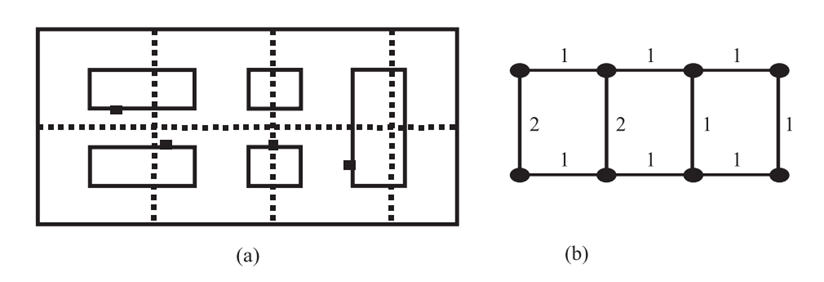

- 定义1：给定一个无向图G(V,E) ，一个要连接的端点集合N(N ⊆ V) ，斯坦纳最小树（SMT）就是一棵通过V 中的点连接N 中所有点的生成树，以最小化边长总和为目标.。
- 定义2：斯坦纳树中，若该斯坦纳树的每条边均为直角矩形边，则此斯坦纳树称为**直角斯坦纳树**。
- 定义3：**最小直角斯坦纳树**（RSMT）两点间的距离是横轴距离和纵轴距离之和，即连线只有水平和垂直两种形式。

## Hanna定理
任意一棵最小直角斯坦纳树T的斯坦纳点均在经过T的水平线和竖直线的交点（Hanna网格）上。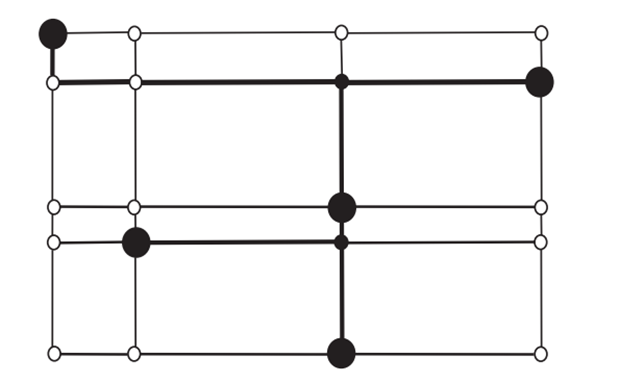

## 解决方法：

求一个端点集合 N 的 最小直角斯坦纳树RSMT，可以通过问题所给定的各个待布线端点，各自分别引一条水平线和竖直线，由这些线的交叉点形成Hanan点集合。从Hanan点集合中按一定规则选取部分点作为斯坦纳点用集合S表示，再求N ⋃ S构成的最小直角斯坦纳树。

## 二、实验内容

最小生成树（SMT）可以看作为斯坦纳树（steiner tree）的特殊情况。斯坦纳树由瑞士数学家斯坦纳（J.Steiner，1796—1863）提出，后被广泛用于各种组合优化的学科和应用中。在VLSI设计中，多端线网的最佳布线常常通过构建最小直角斯坦纳树来完成该NP组合优化问题。

本次实验将以最小生成树为起点，练习最小生成树的相关算法，以及斯坦纳树的应用。**数据来源：2021年EDA设计精英挑战大赛**

## 1.导入软件包

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

## 2.读取数据

在这里可以选择读取**txt**文件或者读取**csv**文件

### 读取txt文件

函数CreateGraph()生成 graph 类的一个对象G，并读取文件数据写入到G中，输出G

In [10]:
# takes input from the file and creates a weighted graph
def CreateGraph(filename):
	G = nx.Graph()
	f = open(filename)
	n = int(f.readline())
	wtMatrix = []
	for i in range(n):
		list1 = list(map(int, (f.readline()).split()))
		wtMatrix.append(list1)
	# Adds egdes along with their weights to the graph 
	for i in range(n) :
		for j in range(n)[i:] :
			if wtMatrix[i][j] > 0 :
					G.add_edge(i, j, length = wtMatrix[i][j]) 
	return G

### 读取csv文件

函数CreateGraph_csv()生成 graph 类的一个对象G，并读取文件数据写入到G中，输出G

In [11]:
#导入必要的包
import pandas as pd
# takes input from the file and creates a weighted graph
def CreateGraph_csv(filename):
    #生成 graph 类的一个对象G
	G = nx.Graph()
    #用Pandas读取文件
	df = pd.read_csv(filename,header=None)
    #获取矩阵行（列）数
	n = int(df.loc[0,0])
    #初始化权重矩阵
	wtMatrix = []
    #将demolnp.csv文件的矩阵转到权重矩阵wtMatrix中
	for i in range(1, n + 1):
		list1 = list(df.iloc[i,:])
		wtMatrix.append(list1)
	# 将 egde 及其权重添加到对象G中
	for i in range(n) :
		for j in range(n)[i:] :
			if wtMatrix[i][j] > 0 :
					G.add_edge(i, j, length = wtMatrix[i][j]) 
	return G

ModuleNotFoundError: No module named 'pandas'

 执行CreateGraph()，并指定读取demoInp.txt文件

In [ ]:
G1 = CreateGraph('demoInp.txt')

执行CreateGraph()，并指定读取demoInp.csv文件

In [ ]:
#读取文件
G1 = CreateGraph_csv('demoInp.csv')

---------------------------------------------------------

## 3.可以自行增加语句代码，测试G的属性和method

输出图G中所有的边，包含其两个端点

In [ ]:
print(G1.edges)

提取某条边（1，3）的信息，显示出该信息（这是一个字典，即 ‘length’对应着其数值‘4’）

In [ ]:
print(G1.get_edge_data(1,3))

提取某条边（1，3）关于‘length’的信息，得到该边的长度为4

In [ ]:
print(G1.get_edge_data(1,3)['length'])

输出图G中所有的节点编号

In [ ]:
print(G1.nodes)

## 4.画图

### 函数DrawGraph(G)画出了图G的所有节点和所有边

In [ ]:
def getPos(G):
    return nx.spring_layout(G)
# draws the graph and displays the weights on the edges
def drawGraph(G,pos):
	nx.draw(G, pos, node_color='yellow',with_labels = True)  # with_labels=true is to show the node number in the output graph
	#nx.draw_networkx_nodes(G, pos,node_color='red')  # with_labels=true is to show the node number in the output graph
	edge_labels = nx.get_edge_attributes(G, 'length')
	nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels, font_size = 11) #    prints weight on all the edges





### 划（MST）线函数

In [ ]:
def drawLines(G,pos,mst,color='r'):
	# marks the MST edges with red
	for X in mst:
	 	if (X[0], X[1]) in G.edges():
	 		nx.draw_networkx_edges(G, pos, edgelist = [(X[0], X[1])], width = 2.5, alpha = 0.6, edge_color = color)

执行画图

In [ ]:
pos = getPos(G1)
drawGraph(G1,pos)
plt.show()

## 5.Kruskals算法的实现部分

解决的问题：在给定的图G=(V,E)中寻找一颗生成树（mst），该生成树把V中节点都连接起来，且边权值之和最小。

下面是师兄设计的一个python函数 kruskals(G)：

1. 算法思路参考Kruskel算法

2. 输入参数为上面生成的G ， 

3. 输出参数为mst。mst应该是一个列表,初始化时mst=[]，当确定某条边 e=(vi , vj)是最小生成树的边的时候，应该把e放进mst列表中，即 mst.append(e)。最终输出的mst长度应该为n-1,其中n是图G中顶点个数

4. 函数通过 mst = kruskals(G) 来调用。 

In [ ]:
def kruskals(G):
    #定义mst矩阵
    mst = []
    #定义edges矩阵，用来给边根据权值大小排序
    edges = []
    #标记不同联通分量值
    m = 0
    #获取节点数
    num_node = len(G.nodes())
    #num用来标记每个节点，防止产生环路。
    #初始状态下每个节点的num都不同。
    num = list(range(num_node))#顺序生成0到(num_node - 1)的列表
    #定义num_1，在两个节点要连接成边时，且两个节点的标记都大于等于num_node时，
    #将大的标记及其联通分量改为小的标记值，这里num_1起到了遍历的作用
    num_1 = list(range(num_node))
    #根据边的权重给边进行排序
    for (vi,vj) in G.edges:
        w = G.get_edge_data(vi,vj)['length']#获取边的权值
        edges.append((w,vi,vj))#生成包含权值的列表
    #.sort()会根据第一个数值进行排序，也即是权重w，默认是升序排序
    edges.sort()


    for w,vi,vj in edges:
        #如果mst已经生成完毕，则跳出for循环
        if len(mst) == num_node - 1:
            break
        #当num[i]与num[j]相等即表示会构成环路，不能选
        #只有num[vi]与num[vj]不等时，才可以连成边
        if num[vi] != num[vj]:
        #当num[vi]与num[vj]不等时，有三种情况
        #1.num[vi],num[vj]中有一个大于等于num_node，一个小于num_node。
        #则将大于等于num_node的节点标记值赋值给小于num_node节点的标记值
        #2.如果num[vi],num[vj]都大于等于num_node，
        #则查找节点中所有等于大的标记值的节点，讲小标记值赋值给大标记值的节点
        #3.如果num[vi],num[vj]都小于num_node，
        #则赋值num_node + m (m = 0, 1 ,2 ...) 其中，m表示次数            
            #第一种情况：num[vi]大于等于，num[vj]小于的情况
            if ((num[vi]>=num_node)&(num[vj]<num_node)):
                num[vj] = num[vi]
            #第一种情况：num[vj]大于等于，num[vi]小于的情况    
            elif ((num[vi]<num_node)&(num[vj]>=num_node)):
                num[vi] = num[vj]
            #第二种情况：num[vi],num[vj]都大于num_node，且num[vi]大于num[vj]    
            elif (num[vi]>=num[vj]>=num_node):
                #遍历所有大标记值的节点
                for x in num_1:
                    if(num[x] == num[vi]):
                        #小标记值的赋值给大标记值
                        num[vi] = num[vj] 
            #第二种情况：num[vi],num[vj]都大于num_node，且num[vj]大于num[vi]            
            elif (num[vj]>=num[vi]>=num_node):
                #遍历所有大标记值的节点
                for x in num_1:
                    if(num[x] == num[vj]):
                        #小标记值的赋值给大标记值
                        num[vj] = num[vi] 
            #第三种情况
            elif ((num[vi]<num_node)&(num[vj]<num_node)):
                #给不同联通分量赋不同标记值
                num[vi] = (num_node + m)
                num[vj] = (num_node + m)
                m = m + 1
            e = (vi, vj)
            #将e放进mst列表
            mst.append(e)

    return mst

## 执行代码

最小生成树用蓝色线条表示

In [ ]:
drawGraph(G1,pos)
mst = kruskals(G1)
print("mst:",mst)
drawLines(G1,pos,mst,color='blue')

### 编写函数calcMst(G,mst)：
1. 输入参数是上面生成的图G以及最小生成树mst
2. 输出参数是最小生成树所有边的权值之和
3. 函数通过 mstval = calcMst(G,mst) 来调用，并输出打印 print(mstval)

In [ ]:
def calcMst(G, mst):
    w = 0
    for (i,j) in mst:
        #计算边权值之和
        w += G.get_edge_data(i,j)['length']
    return w

In [ ]:
print("最小生成树权值之和是：",calcMst(G1, mst))

## 6.斯坦纳树的构建

解决的问题：在给定的图G=(V,E)以及给定的若干节点集合U，其中U ⊆ V，寻找一颗生成树，st. 该生成树可以把U中所有节点连接，且生成树的边权值最小化。

斯坦纳树可以通过networkx中库调用来实现，并用红色线条表示。

In [ ]:
# 给定若干节点
givenPoints=[0,4,5]

In [ ]:
import networkx.algorithms.approximation.steinertree  as st
g1=st.steiner_tree(G1,givenPoints)

############## 下面是画图部分 #####################
drawGraph(G1,pos)
drawLines(G1,pos,mst,color='b')
pos_new = dict([(key,pos[key]) for key in givenPoints])
nx.draw_networkx_nodes(g1, pos, nodelist=pos_new, node_color='red')
drawLines(G1,pos,g1.edges(),color='r')

## 三、实验要求

### 1. 执行上述代码，并理解图的基本概念(nodes, edges etc.)

### 2.阅读代码，理解最小生成树的基本原理

### 3.阅读代码，理解斯坦纳树的基本概念及作用

### 4._阅读文章《基于图论的VLSI中最小斯坦纳树问题及其改进算法》的前两页，理解在VLSI过程中，斯坦纳树的使用

### 5.编写代码，实现以下功能：
（1）读取数据文件“net_info.txt”的信息，包括线网编号以及每个线网所连接的pin的位置（根据实验1所学所用的工具）
（2）给定一个任意个整数 N ，读取对应的线网N
（3）把该线网N的所有pin的位置用plt在图形上划出对应的点
（4）根据上面文章思路，建立其对应的斯坦纳树
（5）把斯坦纳树用图形方式显示出来

### 6.提示：

- 首先，通过文件的读取，找到线网中所有的pin集合P以及每个pin的x/y数据（注意，要做数据的重复性的检查，类似实验1中drop_duplicates函数的作用）
- 根据所有pin的x/y数据，确定出整个mesh的所有的点集合U
- 根据点集合U，以及我们需要构造的mesh网状结构，找个合适的方法构造出整个graph图G
- 调用函数st.steiner_tree，并把G和P的信息分别作为参数，即可生成对应斯坦纳树


另外，有一个坑，需要注意安排画图的分工，因为目前的画图代码中，每个点的具体位置是随机给出的，需要我们想办法设置固定位置给某一个点（当然，需要与 net_info.txt的信息吻合）。


In [ ]:
def read_net_info(filename):
    nets = {}
    with open(filename, 'r') as f:
        next(f, None)  # Skip header line
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            # 添加一个检查，如果一行的第一个部分不是数字，就跳过这一行
            if not parts[0].isdigit():
                continue
            net_id = int(parts[0])
            pin_coords = (int(parts[1]), int(parts[2]))
            if net_id not in nets:
                nets[net_id] = []
            if pin_coords not in nets[net_id]:
                nets[net_id].append(pin_coords)
    return nets

def get_net_pins(nets, net_id):
    return nets.get(net_id, [])

def create_mesh_graph(pins):
    G = nx.Graph()
    all_x = sorted(list(set([p[0] for p in pins])))
    all_y = sorted(list(set([p[1] for p in pins])))
    
    hanan_points = []
    for x in all_x:
        for y in all_y:
            hanan_points.append((x,y))

    for p in hanan_points:
        G.add_node(p)

    point_to_index = {point: i for i, point in enumerate(hanan_points)}

    for i in range(len(hanan_points)):
        for j in range(i + 1, len(hanan_points)):
            p1 = hanan_points[i]
            p2 = hanan_points[j]
            if p1[0] == p2[0] or p1[1] == p2[1]: # Only connect points on same horizontal or vertical line
                dist = abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])
                G.add_edge(p1, p2, length=dist)
    return G

def plot_steiner_tree(G, pins, steiner_tree):
    pos = {node: (node[0], node[1]) for node in G.nodes()}
    
    plt.figure(figsize=(8, 8))
    
    # Draw all nodes in the Hanan grid
    nx.draw_networkx_nodes(G, pos, nodelist=G.nodes(), node_size=20, node_color='gray', alpha=0.5)
    
    # Highlight the pins of the net
    nx.draw_networkx_nodes(G, pos, nodelist=pins, node_size=100, node_color='red')
    
    # Draw the edges of the Steiner tree
    nx.draw_networkx_edges(steiner_tree, pos, edge_color='blue', width=1.5)

    # Highlight the Steiner points
    steiner_points = [n for n in steiner_tree.nodes() if n not in pins]
    if steiner_points:
        nx.draw_networkx_nodes(steiner_tree, pos, nodelist=steiner_points, node_size=100, node_color='green')

    plt.title("Steiner Tree for Net")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import re

def read_net_info(filename):
    nets = {}
    with open(filename, 'r') as f:
        current_net_id = None
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            net_match = re.match(r'net(\d+)', line)
            if net_match:
                current_net_id = int(net_match.group(1))
                nets[current_net_id] = []
                continue
            
            if current_net_id is not None:
                # This is a pin line
                try:
                    parts = line.split(',')
                    if len(parts) == 3:
                        # Format: 0,x,y
                        x = int(parts[1])
                        y = int(parts[2])
                        nets[current_net_id].append((x, y))
                except (ValueError, IndexError):
                    continue
    return nets

def get_net_pins(nets, net_id):
    return nets.get(net_id)

def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def plot_steiner_tree_approximation(pins, mst_edges, net_id):
    plt.figure(figsize=(10, 10))
    
    # 绘制pins
    pin_x = [p[0] for p in pins]
    pin_y = [p[1] for p in pins]
    plt.scatter(pin_x, pin_y, c='red', zorder=5, label='Pins')

    # 绘制MST边
    for u, v in mst_edges:
        # 绘制L型连接
        plt.plot([u[0], v[0]], [u[1], u[1]], 'b-')
        plt.plot([v[0], v[0]], [u[1], v[1]], 'b-')

    plt.title(f'Steiner Tree Approximation for Net {net_id}')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.grid(True)
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# 1. 读取数据文件
nets = read_net_info('net_info.txt')

# 2. 给定一个线网N
net_id_to_process = 1  # 可以更改这个N
pins_of_net = get_net_pins(nets, net_id_to_process)

if pins_of_net:
    # 3. 创建一个完整的图
    G = nx.Graph()
    for i in range(len(pins_of_net)):
        for j in range(i + 1, len(pins_of_net)):
            p1 = pins_of_net[i]
            p2 = pins_of_net[j]
            distance = manhattan_distance(p1, p2)
            G.add_edge(p1, p2, weight=distance)

    # 4. 计算最小生成树（作为Steiner树的近似）
    mst = nx.minimum_spanning_tree(G)

    # 5. 把斯坦纳树（的近似）用图形方式显示出来
    plot_steiner_tree_approximation(pins_of_net, mst.edges(), net_id_to_process)
else:
    print(f"Net {net_id_to_process} not found or has no pins.")